True parameter:
  scale = 2.0
Method of Moments estimate:
  scale = 1.8372968262950156
Maximum Likelihood estimate:
  scale = 1.8372968262950156


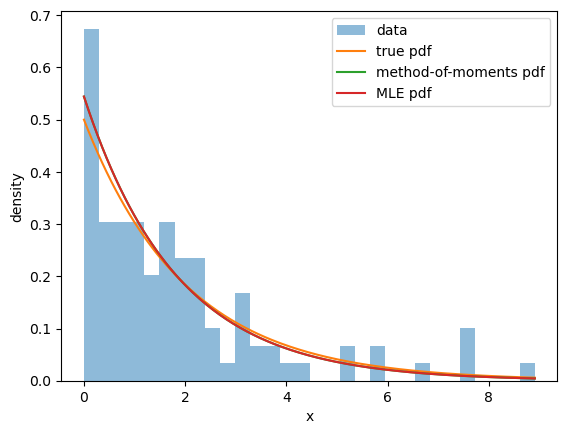

In [4]:
import numpy as np
from scipy import optimize, stats

import matplotlib.pyplot as plt

np.random.seed(0)

# generate sample data from an exponential distribution
true_scale = 2.0
x = np.random.exponential(scale=true_scale, size=100)

# Method of moments estimate for exponential: mean = scale
mom_scale = np.mean(x)

# Maximum likelihood estimation for exponential
def log_likelihood(params, data):
    scale = params[0]
    if scale <= 0:
        return np.inf
    return np.sum(stats.expon.logpdf(data, scale=scale))

initial_guess = [mom_scale]
result = optimize.minimize(
    log_likelihood,
    x0=initial_guess,
    args=(x,),
    bounds=[(1e-6, None)]
)

mle_scale = result.x[0]

print("True parameter:")
print("  scale =", true_scale)
print("Method of Moments estimate:")
print("  scale =", mom_scale)
print("Maximum Likelihood estimate:")
print("  scale =", mle_scale)

plt.hist(x, bins=30, density=True, alpha=0.5, label="data")
xs = np.linspace(0, np.max(x), 200)
plt.plot(xs, stats.expon.pdf(xs, scale=true_scale), label="true pdf")
plt.plot(xs, stats.expon.pdf(xs, scale=mom_scale), label="method-of-moments pdf")
plt.plot(xs, stats.expon.pdf(xs, scale=mle_scale), label="MLE pdf")
plt.legend()
plt.xlabel("x")
plt.ylabel("density")
plt.show()